# COMPAS Explainability (HW2)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

df = df[(df["days_b_screening_arrest"] <= 30) & (df["days_b_screening_arrest"] >= -30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

In [3]:
features = ["age", "race", "sex", "priors_count", "c_charge_degree"]
target = "two_year_recid"

X = df[features]
y = df[target].astype(int)

numeric_features = ["age", "priors_count"]
category_features = ["race", "sex", "c_charge_degree"]

In [4]:
preprocessor = ColumnTransformer([
("num", StandardScaler(), numeric_features),
("cat", OneHotEncoder(handle_unknown="ignore"), category_features)
])

model = Pipeline([
("preprocessor", preprocessor),
("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'sex',
                                                   'c_charge_degree'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## SHAP

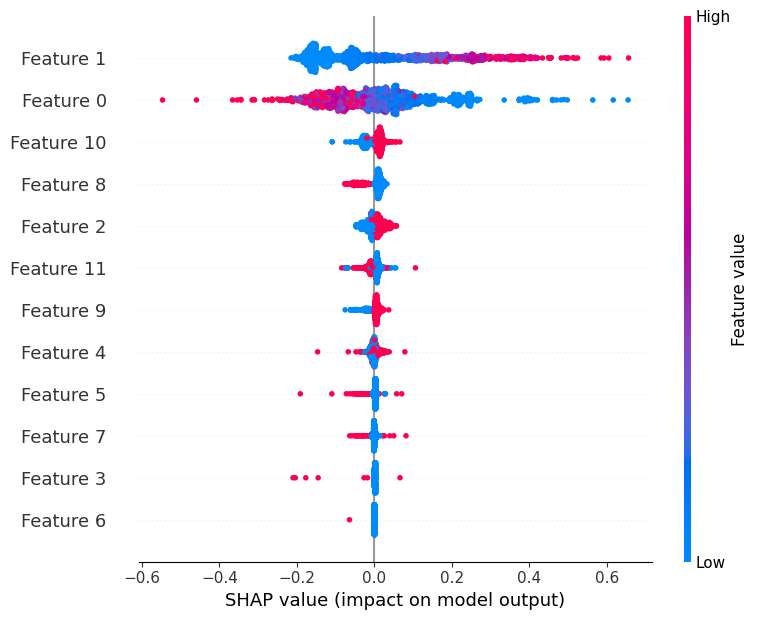

In [8]:
import shap

# Get the fitted preprocessor from the pipeline
fitted_preprocessor = model.named_steps['preprocessor']

# Transform X_train using this fitted preprocessor for the background dataset
# This is the data the classifier was actually trained on after preprocessing
X_train_enc_for_shap = fitted_preprocessor.transform(X_train)

# Transform X_test using the same fitted preprocessor for the samples to be explained
X_test_enc = fitted_preprocessor.transform(X_test)

# Initialize the explainer with the classifier and the correct background data
# For tree models, `shap.Explainer` with a data array will default to `TreeExplainer`
# Using X_train_enc_for_shap as background data, which matches the classifier's input
# Explicitly set model_output to 'probability' for classification models to ensure additivity check passes.
explainer = shap.Explainer(model["classifier"], X_train_enc_for_shap, model_output="probability")

# Calculate SHAP values for the preprocessed test data
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc)

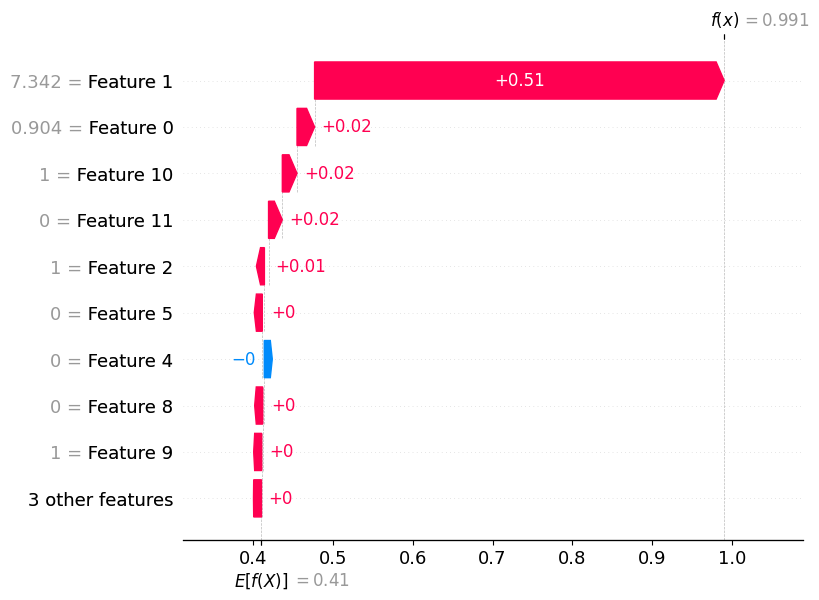

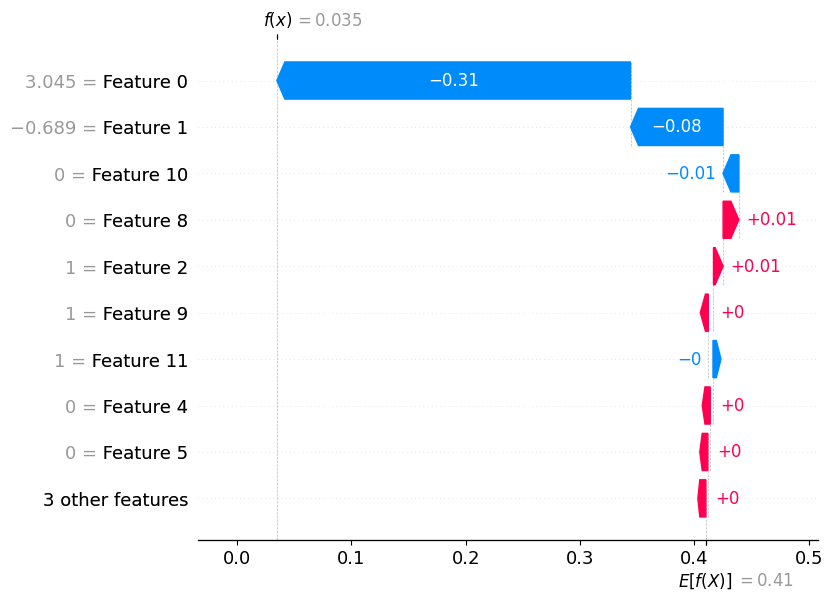

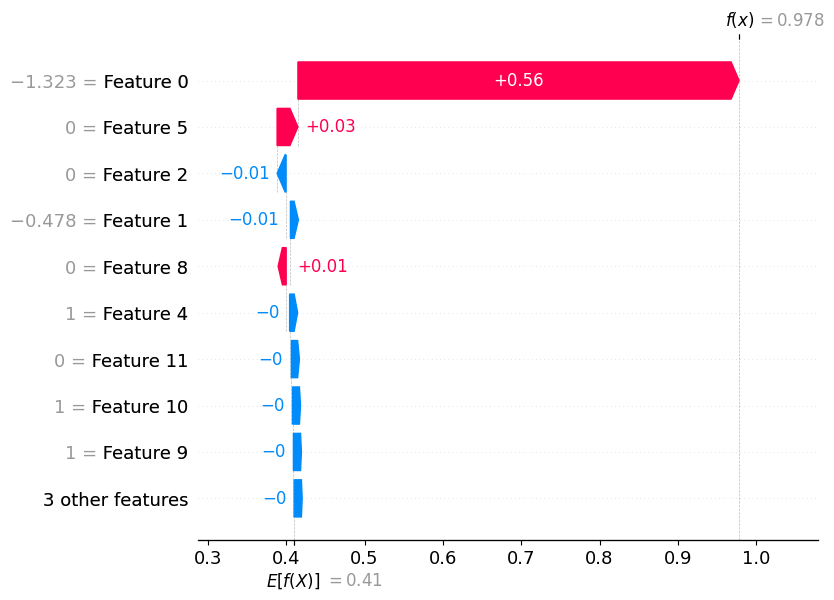

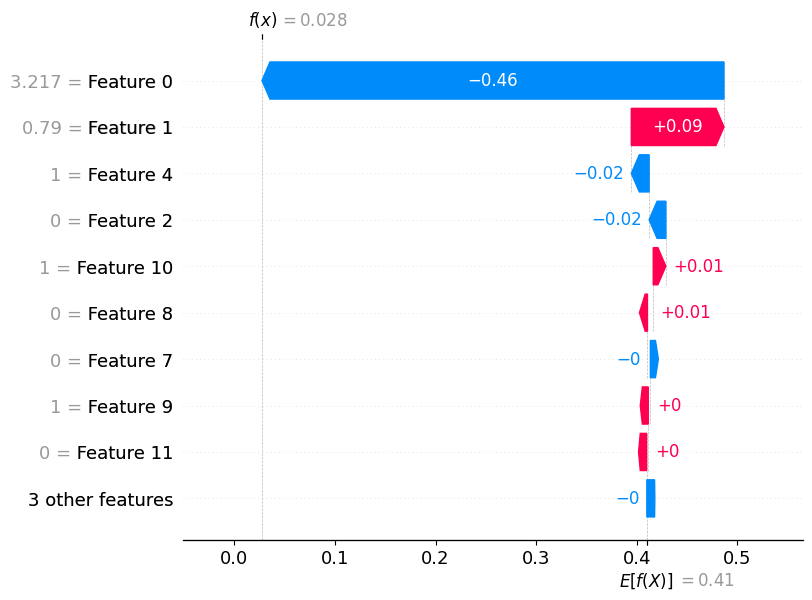

In [9]:
X_test_copy = X_test.copy()
X_test_copy["pred"] = model.predict_proba(X_test)[:,1]

bh = X_test_copy[X_test_copy["race"]=="African-American"].sort_values("pred", ascending=False).index[0]
bl = X_test_copy[X_test_copy["race"]=="African-American"].sort_values("pred").index[0]
wh = X_test_copy[X_test_copy["race"]=="Caucasian"].sort_values("pred", ascending=False).index[0]
wl = X_test_copy[X_test_copy["race"]=="Caucasian"].sort_values("pred").index[0]

for i in [bh, bl, wh, wl]:
    shap.waterfall_plot(shap_values[X_test.index.get_loc(i)])

## LIME

In [12]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
X_train_enc = preprocessor.fit_transform(X_train)

lime_exp = LimeTabularExplainer(X_train_enc, mode="classification")

idx = bh
row = preprocessor.transform(X_test.loc[[idx]])

exp = lime_exp.explain_instance(row[0], model["classifier"].predict_proba)
exp.show_in_notebook()

LIME vs SHAP: agree on priors and age, but they differ in stability governance, and requires multiple methods.

## Counterfactuals

In [14]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice

dice_data = dice_ml.Data(dataframe=pd.concat([X_train, y_train], axis=1), continuous_features=numeric_features, outcome_name=target)
dice_model = dice_ml.Model(model=model, backend="sklearn")

dice = Dice(dice_data, dice_model, method="random")

cf = dice.generate_counterfactuals(X_test.iloc[[0]], total_CFs=1, desired_class="opposite")
cf.visualize_as_dataframe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 20.0 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  8.37it/s]

Query instance (original outcome : 0)


,age,race,sex,priors_count,c_charge_degree,two_year_recid
0,21,Hispanic,Male,4,F,0



Diverse Counterfactual set (new outcome: 1)


,age,race,sex,priors_count,c_charge_degree,two_year_recid
0,40,Hispanic,Male,4,F,1


Counterfactuals: change priors/age. Race/sex invalid.